In [ ]:
# 1. Mount Google Drive và Cài đặt thư viện
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers faiss-cpu pandas pillow tqdm

# 2. Xóa dữ liệu lỗi cũ và Giải nén lại từ đầu
import os
!rm -rf /content/local_data
!rm -f /content/test.zip

zip_path_on_drive = '/content/drive/MyDrive/test.zip'
local_zip_path = '/content/test.zip'
local_data_dir = '/content/local_data'

print("⏳ Đang copy file nén từ Drive và giải nén (sẽ mất khoảng vài chục giây)...")
# Kiểm tra xem file zip có tồn tại trên Drive không
if not os.path.exists(zip_path_on_drive):
    raise FileNotFoundError(f"❌ KHÔNG TÌM THẤY FILE: {zip_path_on_drive}. Vui lòng kiểm tra lại xem bạn đã up file test.zip lên đúng thư mục MyDrive ngoài cùng chưa!")

!cp "{zip_path_on_drive}" "{local_zip_path}"
!mkdir -p "{local_data_dir}"
!unzip -q "{local_zip_path}" -d "{local_data_dir}/"
print("✅ Giải nén hoàn tất vào ổ cứng nội bộ!")

# 3. Import thư viện
import torch
print('CUDA VERSION : ', torch.version.cuda)
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import random
import numpy as np
from transformers import ViTModel
from tqdm import tqdm
import pandas as pd
from glob import glob
import faiss

# 4. Khai báo thư mục và Tạo Metadata
# FIX LỖI: Trỏ thẳng vào thư mục chứa đồ giải nén, không ép cứng phải có chữ "test"
DATA_ROOT = local_data_dir

save_dir = '/content/drive/MyDrive/test/SAVE'
os.makedirs(save_dir, exist_ok=True)

# Quét ảnh và tạo file csv
image_paths = []
for ext in ['*.png', '*.jpg', '*.jpeg']:
    image_paths.extend(glob(os.path.join(DATA_ROOT, '**', ext), recursive=True))

if len(image_paths) == 0:
    print("❌ LỖI: Không tìm thấy bất kỳ ảnh nào! Vui lòng kiểm tra lại file test.zip trên Drive của bạn có chứa ảnh bên trong không.")
else:
    records = []
    for full_path in image_paths:
        rel_path = os.path.relpath(full_path, DATA_ROOT)
        logo_id = os.path.splitext(os.path.basename(full_path))[0]
        records.append({'filename': rel_path, 'logo_id': logo_id})

    df = pd.DataFrame(records)
    metadata_path = os.path.join(DATA_ROOT, 'metadata.csv')
    df.to_csv(metadata_path, index=False)
    print(f"✅ Đã tạo Metadata. Quét thành công {len(df)} ảnh logo tại máy ảo.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Đang copy file nén từ Drive và giải nén (sẽ mất khoảng vài chục giây)...
✅ Giải nén hoàn tất vào ổ cứng nội bộ!
CUDA VERSION :  12.8
✅ Đã tạo Metadata. Quét thành công 3795 ảnh logo tại máy ảo.


## DATA

In [ ]:
# --- Hàm đọc ảnh an toàn ---
def load_safe_image(img_path):
    try:
        img = Image.open(img_path)
        if img.mode in ('RGBA', 'LA', 'P'):
            img = img.convert('RGBA')
            background = Image.new('RGBA', img.size, (255, 255, 255))
            background.paste(img, mask=img)
            return background.convert('RGB')
        else:
            return img.convert('RGB')
    except Exception as e:
        print(f"Lỗi đọc ảnh {img_path}: {e}")
        return Image.new('RGB', (224, 224), (255, 255, 255))

# --- Dataset ---
class LogoPairDataset(Dataset):
    def __init__(self, metadata_df, raw_dir, transform=None, mode='train'):
        self.metadata = metadata_df
        self.raw_dir = raw_dir
        self.transform = transform if transform else self._default_transform(mode)
        self.mode = mode
        self.pairs = self._build_pairs()

    def _default_transform(self, mode):
        if mode == 'train':
            return transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.RandomRotation(15),
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
                transforms.RandomGrayscale(p=0.2),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
            ])
        else:
            return transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
            ])

    def _build_pairs(self):
        logo_to_files = self.metadata.groupby('logo_id')['filename'].apply(list).to_dict()
        pairs = []
        for logo, files in logo_to_files.items():
            n = len(files)
            if n >= 2:
                for i in range(min(10, n)):
                    for j in range(i+1, min(10, n)):
                        pairs.append((files[i], files[j], 1))
            else:
                pairs.append((files[0], files[0], 1))
        all_logos = list(logo_to_files.keys())
        num_neg = len(pairs)
        for _ in range(num_neg):
            logo1, logo2 = random.sample(all_logos, 2)
            img1 = random.choice(logo_to_files[logo1])
            img2 = random.choice(logo_to_files[logo2])
            pairs.append((img1, img2, 0))
        random.shuffle(pairs)
        return pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        imgA_path, imgB_path, label = self.pairs[idx]
        imgA = load_safe_image(os.path.join(self.raw_dir, imgA_path))
        imgB = load_safe_image(os.path.join(self.raw_dir, imgB_path))
        if self.transform:
            imgA = self.transform(imgA)
            imgB = self.transform(imgB)
        return imgA, imgB, torch.tensor(label, dtype=torch.float32)

# --- Định nghĩa model ---
class ViTEncoder(nn.Module):
    def __init__(self, model_name='google/vit-base-patch16-224'):
        super().__init__()
        self.vit = ViTModel.from_pretrained(model_name)

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        return outputs.pooler_output

class SiameseNetwork(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward_once(self, x):
        return self.backbone(x)

    def forward(self, imgA, imgB):
        embA = self.forward_once(imgA)
        embB = self.forward_once(imgB)
        return embA, embB

# --- Contrastive Loss (Dựa trên Cosine) ---
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=0.5):
        super().__init__()
        self.margin = margin

    def forward(self, embA, embB, label):
        embA_norm = F.normalize(embA, p=2, dim=1)
        embB_norm = F.normalize(embB, p=2, dim=1)
        cosine_sim = torch.sum(embA_norm * embB_norm, dim=1)
        distance = 1.0 - cosine_sim
        loss = label * torch.pow(distance, 2) + \
               (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2)
        return loss.mean()

## TRAIN

In [ ]:
import torch
import torch.nn.functional as F
import os
from tqdm import tqdm
from torch.utils.data import DataLoader
import pandas as pd

# --- Cấu hình Hyperparameters ---
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-4
MARGIN = 0.5
THRESHOLD = 0.5 # Ngưỡng tính Accuracy
PATIENCE = 5    # Số epoch chờ tối đa nếu Val Loss không giảm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# --- Chuẩn bị Dữ liệu ---
df = pd.read_csv(metadata_path)
full_dataset = LogoPairDataset(df, DATA_ROOT, mode='train')
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

NUM_WORKERS = 2
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# --- Khởi tạo Mô hình ---
backbone = ViTEncoder()
model = SiameseNetwork(backbone).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = ContrastiveLoss(margin=MARGIN)
scaler = torch.amp.GradScaler('cuda')

# --- Biến theo dõi Early Stopping ---
best_val_loss = float('inf')
patience_counter = 0

# --- Vòng lặp Huấn luyện ---
for epoch in range(EPOCHS):
    # 1. TRAIN
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for imgA, imgB, label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Train"):
        imgA, imgB, label = imgA.to(DEVICE), imgB.to(DEVICE), label.to(DEVICE)

        optimizer.zero_grad()
        with torch.autocast(device_type='cuda'):
            embA, embB = model(imgA, imgB)
            loss = criterion(embA, embB, label)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        # Tính Train Accuracy
        with torch.no_grad():
            cos_sim = F.cosine_similarity(embA, embB)
            preds = (cos_sim > THRESHOLD).float()
            train_correct += (preds == label).sum().item()
            train_total += label.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total

    # 2. EVALUATION
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgA, imgB, label in val_loader:
            imgA, imgB, label = imgA.to(DEVICE), imgB.to(DEVICE), label.to(DEVICE)
            with torch.autocast(device_type='cuda'):
                embA, embB = model(imgA, imgB)
                loss = criterion(embA, embB, label)

            val_loss += loss.item()

            # Tính Validation Accuracy
            cos_sim = F.cosine_similarity(embA, embB)
            preds = (cos_sim > THRESHOLD).float()
            val_correct += (preds == label).sum().item()
            val_total += label.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    print(f"\nEpoch {epoch+1}/{EPOCHS} - "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

    # 3. EARLY STOPPING & SAVE MODEL
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0  # Reset bộ đếm vì mô hình tốt lên
        torch.save(model.state_dict(), os.path.join(save_dir, 'best_model.pth'))
        print("  --> Saved best model")
    else:
        patience_counter += 1 # Tăng bộ đếm nếu Val Loss không cải thiện
        print(f"  --> EarlyStopping counter: {patience_counter} out of {PATIENCE}")

        if patience_counter >= PATIENCE:
            print(f"🛑 Đã kích hoạt Early Stopping tại Epoch {epoch+1}! Quá trình huấn luyện dừng lại để tránh Overfitting.")
            break

print("🎉 Training process finished!\n")

⚠️ Bỏ qua vẽ biểu đồ Loss vì không tìm thấy biến lưu lịch sử (history_loss).
💡 (Mô hình vẫn đã được lưu thành công, bạn cứ xem Ma trận nhầm lẫn ở dưới nhé)

⏳ Đang load Best Model và tính toán trên tập Validation...


Đang đánh giá Validation: 100%|██████████| 48/48 [00:49<00:00,  1.02s/it]


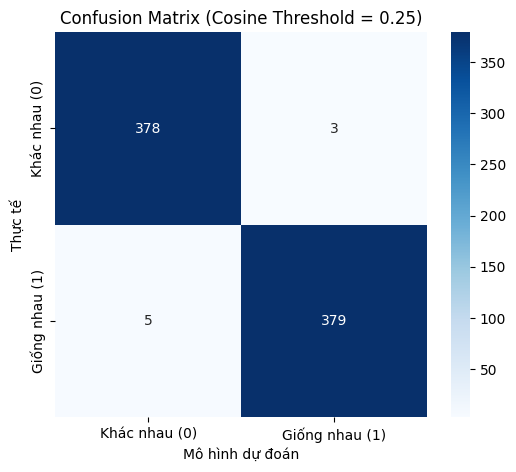

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
import os
from tqdm import tqdm  # Thêm thư viện này để có thanh chạy

# ==========================================
# 1. VẼ BIỂU ĐỒ TRAIN LOSS & VAL LOSS
# ==========================================
if 'history_train_loss' in locals() and 'history_val_loss' in locals():
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(history_train_loss) + 1), history_train_loss, label='Train Loss', marker='o')
    plt.plot(range(1, len(history_val_loss) + 1), history_val_loss, label='Val Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("⚠️ Bỏ qua vẽ biểu đồ Loss vì không tìm thấy biến lưu lịch sử (history_loss).")
    print("💡 (Mô hình vẫn đã được lưu thành công, bạn cứ xem Ma trận nhầm lẫn ở dưới nhé)")

# ==========================================
# 2. TÍNH TOÁN & VẼ MA TRẬN NHẦM LẪN
# ==========================================
print("\n⏳ Đang load Best Model và tính toán trên tập Validation...")

model.load_state_dict(torch.load(os.path.join(save_dir, 'best_model.pth'), map_location=DEVICE))
model.eval()

all_labels = []
all_distances = []

with torch.no_grad():
    # BỌC VAL_LOADER TRONG TQDM ĐỂ THẤY THANH TIẾN TRÌNH CHẠY %
    for imgA, imgB, label in tqdm(val_loader, desc="Đang đánh giá Validation"):
        imgA, imgB = imgA.to(DEVICE), imgB.to(DEVICE)

        with torch.autocast(device_type='cuda'):
            embA, embB = model(imgA, imgB)

            embA_norm = F.normalize(embA, p=2, dim=1)
            embB_norm = F.normalize(embB, p=2, dim=1)
            cosine_sim = torch.sum(embA_norm * embB_norm, dim=1)
            dist = 1.0 - cosine_sim

        all_labels.extend(label.cpu().numpy())
        all_distances.extend(dist.cpu().numpy())

all_labels = np.array(all_labels)
all_distances = np.array(all_distances)

COSINE_MARGIN = 0.5
threshold = COSINE_MARGIN / 2.0  # = 0.25
preds = (all_distances < threshold).astype(int)

cm = confusion_matrix(all_labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Khác nhau (0)', 'Giống nhau (1)'],
            yticklabels=['Khác nhau (0)', 'Giống nhau (1)'])
plt.title(f'Confusion Matrix (Cosine Threshold = {threshold})')
plt.xlabel('Mô hình dự đoán')
plt.ylabel('Thực tế')
plt.show()

## HNSW

In [ ]:
class InferenceDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = load_safe_image(path)
        img_tensor = self.transform(img)
        img_id = os.path.splitext(os.path.basename(path))[0]
        return img_tensor, img_id

def build_faiss_index_hnsw_cosine(model, dataloader, device):
    model.eval()
    embeddings = []
    ids = []

    with torch.no_grad():
        for img_tensors, img_ids in tqdm(dataloader, desc="Encoding images in Batches"):
            img_tensors = img_tensors.to(device)
            with torch.autocast(device_type='cuda'):
                batch_embs = model.backbone(img_tensors)
            embeddings.append(batch_embs.cpu().numpy())
            ids.extend(img_ids)

    embeddings = np.vstack(embeddings).astype('float32')
    faiss.normalize_L2(embeddings) # Bắt buộc cho Cosine

    d = embeddings.shape[1]
    M = 32
    index = faiss.IndexHNSWFlat(d, M, faiss.METRIC_INNER_PRODUCT)
    index.hnsw.efConstruction = 200
    index.add(embeddings)
    return index, ids

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

model.load_state_dict(torch.load(os.path.join(save_dir, 'best_model.pth'), map_location=DEVICE))
model.to(DEVICE)

inference_dataset = InferenceDataset(image_paths, transform)
inference_loader = DataLoader(inference_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

index, ids = build_faiss_index_hnsw_cosine(model, inference_loader, DEVICE)
index.hnsw.efSearch = 128
print(f"FAISS HNSW Cosine index built successfully with {index.ntotal} vectors.")

Encoding images in Batches: 100%|██████████| 30/30 [01:54<00:00,  3.81s/it]


FAISS HNSW Cosine index built successfully with 3795 vectors.


## SIMPLE TEST

In [ ]:
from google.colab import files
from IPython.display import Image as show_image, display
import matplotlib.pyplot as plt

# Upload ảnh query
print("Vui lòng tải ảnh lên từ máy tính của bạn:")
uploaded = files.upload()
query_path = list(uploaded.keys())[0]

def get_query_embedding(image_path, model, device, transform):
    img = load_safe_image(image_path)
    img_tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        with torch.autocast(device_type='cuda'):
            emb = model.backbone(img_tensor).cpu().numpy().flatten().astype('float32').reshape(1, -1)

    faiss.normalize_L2(emb) # Chuẩn hóa theo chuẩn Cosine
    return emb

def search_similar(query_emb, index, ids, top_k=5):
    scores, indices = index.search(query_emb, top_k)
    results = [(ids[idx], float(scores[0][i])) for i, idx in enumerate(indices[0])]
    return results

query_emb = get_query_embedding(query_path, model, DEVICE, transform)
raw_results = search_similar(query_emb, index, ids, top_k=5)

final_results = []
for name, score in raw_results:
    similarity_pct = max(0.0, score * 100.0)
    final_results.append((name, score, similarity_pct))

print("\n🔍 Kết quả tìm kiếm (Cosine Similarity):")
for name, score, pct in final_results:
    print(f"  - {name}: {pct:.2f}% giống (Cosine Sim: {score:.4f})")

def show_results(results, database_paths, top_k=5):
    fig, axes = plt.subplots(1, top_k + 1, figsize=(15, 3.5))

    axes[0].imshow(Image.open(query_path).convert('RGB'))
    axes[0].set_title("Query (Upload)")
    axes[0].axis('off')

    for i, (name, score, pct) in enumerate(results[:top_k]):
        path = [p for p in database_paths if os.path.splitext(os.path.basename(p))[0] == name][0]
        img = Image.open(path).convert('RGB')

        axes[i + 1].imshow(img)
        axes[i + 1].set_title(f"{name}\n{pct:.1f}% giống\n(Sim: {score:.2f})", fontsize=10)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

show_results(final_results, image_paths, top_k=5)